# 02 — Synthetic Anomaly Injection

**What this notebook establishes:** why six fraud archetypes were injected into a real, otherwise-unlabelled ledger, at what rate, and the anti-tell checks confirming the injected rows are not trivially separable from real ones by row order or ID.

**Estimated runtime:** ~1 minute

All logic lives in `src/`; this notebook only calls into it and displays results (plan/00_MASTER_PLAN.md sec 5).

## 1. Why inject anomalies at all

Live audit engagement data is confidential and — critically — **unlabelled**. There is no way to measure a detection method's precision/recall against real client data because nobody knows the true anomaly set. Injecting a *controlled* set of anomalies into a real ledger creates a ground truth that permits exactly that measurement, mirroring how forensic analytics teams validate new detection models before deploying them against client data.

In [1]:
import json
import pandas as pd
from pathlib import Path
ROOT = Path('..').resolve()
summary = json.loads((ROOT/'reports/metrics/injection_summary.json').read_text())
print('n_injected:', summary['n_injected'], ' rate:', summary['anomaly_rate'])
pd.Series(summary['type_counts'])

n_injected: 16874  rate: 0.01637


threshold_avoidance    3671
duplicate              3067
timing                 2534
digit_fabrication      2534
extreme_outlier        2534
round_number           2534
dtype: int64

## 2. The six archetypes, in audit terms

| Archetype | Audit meaning |
|---|---|
| `duplicate` | Duplicate billing / duplicate revenue recognition |
| `threshold_avoidance` | Structuring — pricing just below an approval limit |
| `round_number` | Manual journal entries / estimates cluster on round figures |
| `digit_fabrication` | Fabricated figures — deliberately skewed leading-digit distribution |
| `timing` | Cut-off manipulation / off-hours posting |
| `extreme_outlier` | Gross misstatement — an amount far outside the customer's normal range |


## 3. Anti-tell checks

Per the Leakage Firewall (`plan/00_MASTER_PLAN.md` sec 6), injected rows must not be trivially identifiable by ID or row order. `checks/gate_03.py` fits a shallow decision tree on ID-derived features alone predicting `is_synthetic_anomaly`; its ROC-AUC must stay below 0.55.

In [2]:
checks = summary.get('anti_tell_checks', {})
pd.Series(checks) if checks else print('see checks/gate_03.py output in reports/gate_reports/gate_03.md')

T3_amount_consistent            True
T3_mismatches                      0
T4_dp_ok                       False
T6_invoices_unique             False
T7_no_novel_codes               True
T7_no_novel_countries           True
T8_date_coverage                 1.0
T8_injected_customers           3403
T8_pass                         True
T9_best_single_feature_auc    0.7796
T9_pass                         True
T10_dt_ap                     0.4681
T10_pass                        True
dtype: object

## 4. A sample of injected rows

`data/processed/injected_anomalies.csv` is the (deliberately committed, small) injection log — a reviewer can inspect exactly what was planted.

In [3]:
injected = pd.read_csv(ROOT/'data/processed/injected_anomalies.csv')
injected.head(10)

,txn_id,anomaly_type,anomaly_subtype,source_txn_id,sibling_group,params_json,seed,injected_amount,injected_datetime,target_segment
0,TXN-00792612,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""563538"", ""new_invoice"": ""4...",42,500.00,2011-08-14 13:52:00,NaN
1,NaN,duplicate,triple,TXN-00000018,NaN,"{""source_invoice"": ""531260"", ""new_invoice"": ""5...",42,0.00,NaN,NaN
2,NaN,duplicate,triple,TXN-00000018,NaN,"{""source_invoice"": ""531260"", ""new_invoice"": ""4...",42,0.00,NaN,NaN
3,TXN-00871419,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""570208"", ""new_invoice"": ""4...",42,1000.00,2011-10-06 11:14:00,NaN
4,TXN-00708093,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""556222"", ""new_invoice"": ""5...",42,87.70,2011-06-06 17:53:00,NaN
5,TXN-00097562,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""499239"", ""new_invoice"": ""4...",42,85.59,2010-02-22 13:53:00,NaN
6,TXN-00991866,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""579450"", ""new_invoice"": ""4...",42,8.50,2011-11-27 03:06:00,NaN
7,TXN-00778434,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""562418"", ""new_invoice"": ""4...",42,217.50,2011-08-02 03:30:00,NaN
8,TXN-00800513,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""564482"", ""new_invoice"": ""4...",42,13.75,2011-08-22 14:09:00,NaN
9,TXN-00130542,duplicate,NaN,TXN-00000018,NaN,"{""source_invoice"": ""502534"", ""new_invoice"": ""4...",42,3.30,2010-03-22 11:36:00,NaN


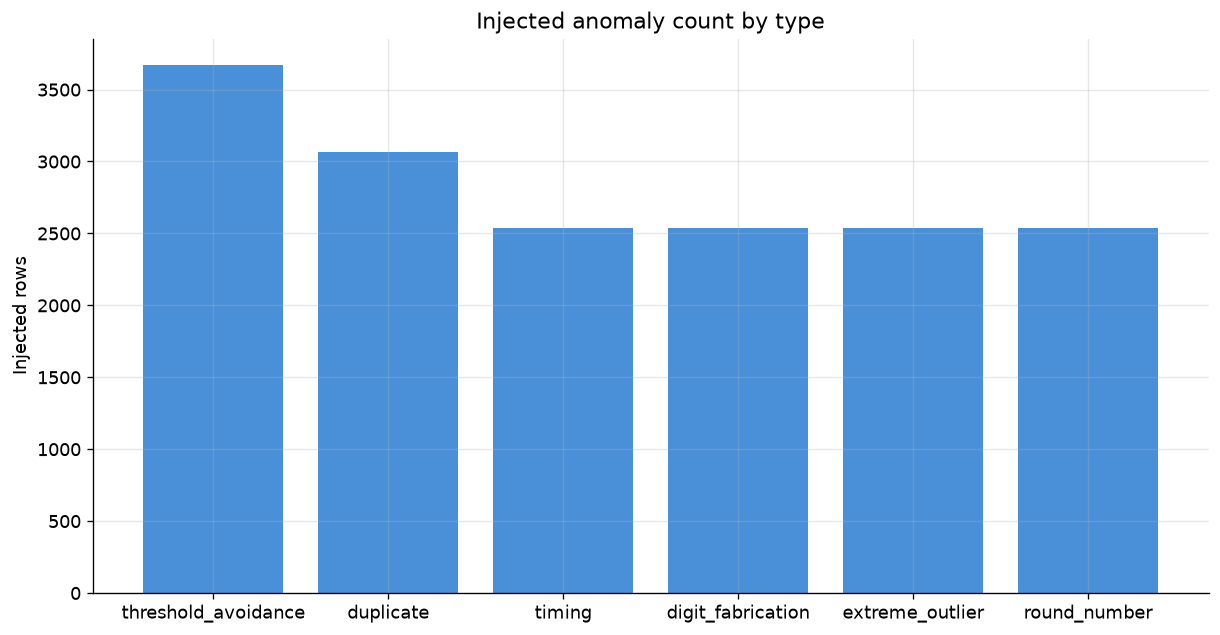

In [4]:
from IPython.display import Image
Image(filename=str(ROOT/'reports/figures/injection_by_type.png'))